In [18]:
!pip install pandas nltk textblob matplotlib seaborn wordcloud scikit-learn

In [21]:
import pandas as pd
import numpy as np
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [22]:
df = pd.read_csv("hotel_reviews.csv")

df.head()

,Review
0,Room was very clean and staff were friendly.
1,Food was terrible and service was slow.
2,Excellent hotel with amazing facilities.
3,Bathroom was dirty and room smelled bad.
4,Breakfast was delicious and staff was helpful.


In [23]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)

df.head()

,Review,Cleaned_Review
0,Room was very clean and staff were friendly.,room clean staff friendly
1,Food was terrible and service was slow.,food terrible service slow
2,Excellent hotel with amazing facilities.,excellent hotel amazing facility
3,Bathroom was dirty and room smelled bad.,bathroom dirty room smelled bad
4,Breakfast was delicious and staff was helpful.,breakfast delicious staff helpful


In [24]:
def get_sentiment(review):

    polarity = TextBlob(review).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Cleaned_Review'].apply(get_sentiment)

df.head()

,Review,Cleaned_Review,Sentiment
0,Room was very clean and staff were friendly.,room clean staff friendly,Positive
1,Food was terrible and service was slow.,food terrible service slow,Negative
2,Excellent hotel with amazing facilities.,excellent hotel amazing facility,Positive
3,Bathroom was dirty and room smelled bad.,bathroom dirty room smelled bad,Negative
4,Breakfast was delicious and staff was helpful.,breakfast delicious staff helpful,Positive


In [25]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    6
Negative    4
Name: count, dtype: int64


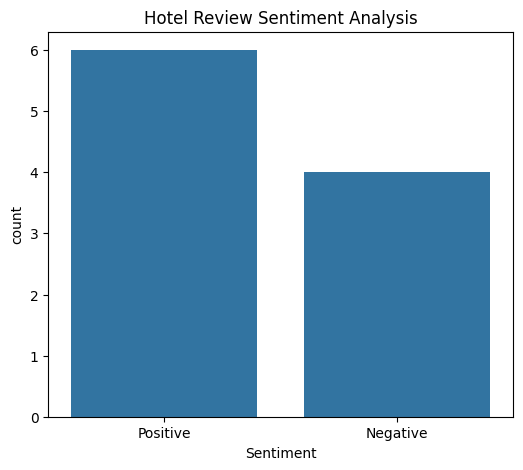

In [26]:
plt.figure(figsize=(6,5))

sns.countplot(x='Sentiment', data=df)

plt.title("Hotel Review Sentiment Analysis")

plt.show()

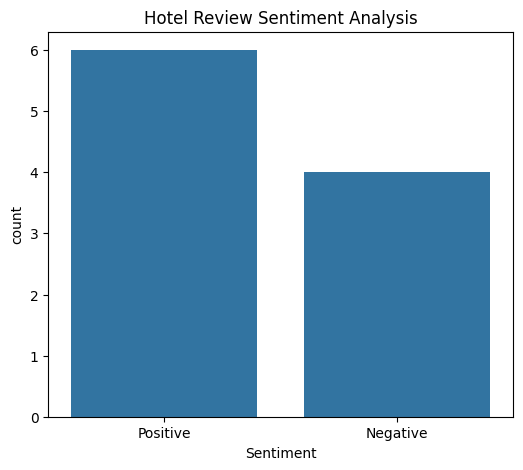

In [27]:
plt.figure(figsize=(6,5))

sns.countplot(x='Sentiment', data=df)

plt.title("Hotel Review Sentiment Analysis")

plt.show()

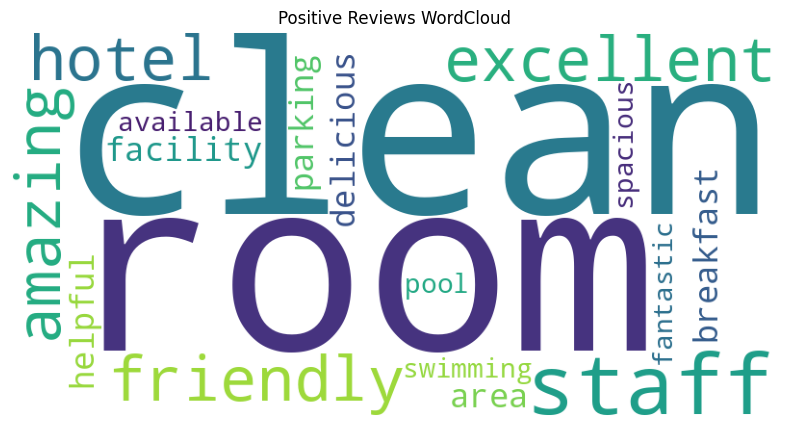

In [28]:
positive = " ".join(df[df['Sentiment']=="Positive"]['Cleaned_Review'])

wordcloud = WordCloud(width=800,height=400,background_color='white').generate(positive)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews WordCloud")

plt.show()

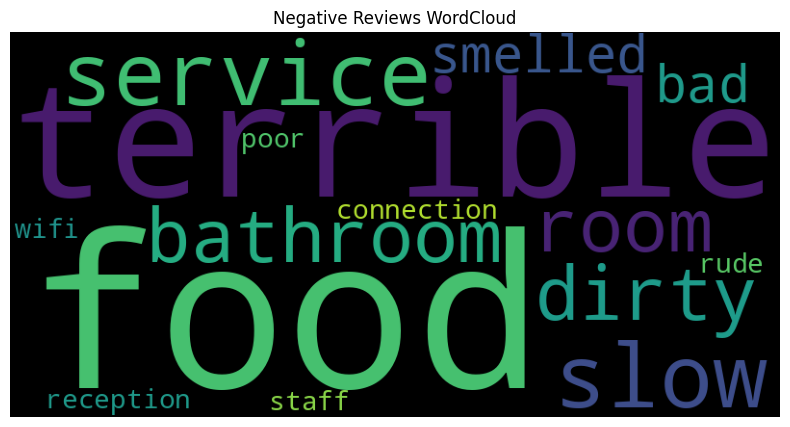

In [29]:
negative = " ".join(df[df['Sentiment']=="Negative"]['Cleaned_Review'])

wordcloud = WordCloud(width=800,height=400,background_color='black').generate(negative)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Reviews WordCloud")

plt.show()

In [30]:
issues = {
    "Room":["room","bed","bathroom"],
    "Staff":["staff","employee","manager","reception"],
    "Food":["food","breakfast","restaurant","meal"],
    "Cleanliness":["clean","dirty","hygiene"],
    "Amenities":["wifi","pool","gym","parking","ac"]
}

def identify_issue(review):

    review = review.lower()

    found=[]

    for category, words in issues.items():

        for word in words:

            if word in review:
                found.append(category)
                break

    if len(found)==0:
        return "Other"

    return ", ".join(found)

df['Issue_Category'] = df['Cleaned_Review'].apply(identify_issue)

df[['Review','Issue_Category']].head()

,Review,Issue_Category
0,Room was very clean and staff were friendly.,"Room, Staff, Cleanliness"
1,Food was terrible and service was slow.,Food
2,Excellent hotel with amazing facilities.,Amenities
3,Bathroom was dirty and room smelled bad.,"Room, Cleanliness"
4,Breakfast was delicious and staff was helpful.,"Staff, Food"


In [31]:
issue_count = df['Issue_Category'].value_counts()

print(issue_count)

Issue_Category
Amenities                       4
Room, Staff, Cleanliness        1
Food                            1
Room, Cleanliness               1
Staff, Food                     1
Staff                           1
Room, Cleanliness, Amenities    1
Name: count, dtype: int64


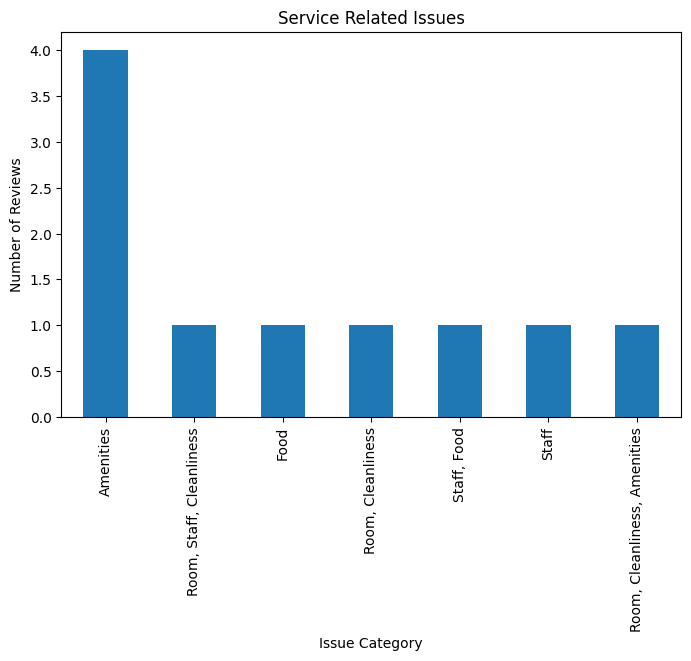

In [32]:
plt.figure(figsize=(8,5))

issue_count.plot(kind='bar')

plt.title("Service Related Issues")

plt.xlabel("Issue Category")

plt.ylabel("Number of Reviews")

plt.show()

In [33]:
total = len(df)

positive = len(df[df['Sentiment']=="Positive"])

negative = len(df[df['Sentiment']=="Negative"])

neutral = len(df[df['Sentiment']=="Neutral"])

print("Total Reviews :", total)

print("Positive :", positive)

print("Negative :", negative)

print("Neutral :", neutral)

print("Customer Satisfaction =", round((positive/total)*100,2),"%")

Total Reviews : 10
Positive : 6
Negative : 4
Neutral : 0
Customer Satisfaction = 60.0 %


In [34]:
df.to_csv("Hotel_Review_Analysis_Report.csv", index=False)

print("Report Saved Successfully")

Report Saved Successfully
